In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import shutil

# === CONFIGURE THESE ===
SOURCE_ROOT = "/kaggle/input/datasets/zarinsaimaroza/numismatic-heritage-of-coin-dataset-bangladesh/Numismatic Heritage of Coin Dataset Bangladesh"
DEST_ROOT = "/kaggle/working/coin_dataset_organized"

# === MAPPING: source folder → simplified class ===
FOLDER_MAP = {
    # 1 Taka
    "1Taka _1993Back": "1b",
    "1Taka_1999Back": "1b",
    "1Taka_2003Back": "1b",
    "1Taka_2014Back": "1b",
    "1Taka_1993Front": "1f",
    "1Taka_1999Front": "1f",
    "1Taka_2003Front": "1f",
    "1Taka_2014Front": "1f",

    # 2 Taka
    "2Taka_2008Back": "2b",
    "2Taka_2013Back": "2b",
    "2Taka_2008Front": "2f",
    "2Taka_2013Front": "2f",

    # 5 Taka
    "5Taka_2008Back": "5b",
    "5Taka_2012Back": "5b",
    "5Taka_2008Front": "5f",
    "5Taka_2012Front": "5f",
}

def organize_dataset():
    taka_parents = {
        "1 Taka Coin": os.path.join(SOURCE_ROOT, "1 Taka Coin"),
        "2 Taka Coin": os.path.join(SOURCE_ROOT, "2 Taka Coin"),
        "5 Taka Coin": os.path.join(SOURCE_ROOT, "5 Taka Coin"),
    }

    # class_files[class_name][source_subfolder] = list of dest filepaths
    # This grouping is what lets the split step stratify by year later.
    class_files = {}

    copied = 0
    skipped = 0

    for parent_name, parent_path in taka_parents.items():
        if not os.path.exists(parent_path):
            print(f"⚠️  Not found: {parent_path}")
            continue

        for subfolder in os.listdir(parent_path):
            subfolder_path = os.path.join(parent_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue

            if subfolder not in FOLDER_MAP:
                print(f"⚠️  No mapping for: {subfolder} — skipping")
                skipped += 1
                continue

            dest_class = FOLDER_MAP[subfolder]
            dest_path = os.path.join(DEST_ROOT, dest_class)
            os.makedirs(dest_path, exist_ok=True)

            class_files.setdefault(dest_class, {}).setdefault(subfolder, [])

            for img_file in os.listdir(subfolder_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                    src = os.path.join(subfolder_path, img_file)
                    new_name = f"{subfolder}_{img_file}"
                    dst = os.path.join(dest_path, new_name)
                    shutil.copy2(src, dst)
                    class_files[dest_class][subfolder].append(dst)
                    copied += 1

    print(f"\n✅ Done! Copied {copied} images, skipped {skipped} unknown folders.")

    print("\n📊 Class Summary (by year source):")
    for class_name in sorted(class_files.keys()):
        total = sum(len(v) for v in class_files[class_name].values())
        print(f"\n  {class_name} → {total} images total")
        for sub, files in class_files[class_name].items():
            print(f"     {sub:25s} → {len(files)} images")

    return class_files

class_files = organize_dataset()


✅ Done! Copied 5719 images, skipped 0 unknown folders.

📊 Class Summary (by year source):

  1b → 1395 images total
     1Taka_2003Back            → 353 images
     1Taka_2014Back            → 336 images
     1Taka _1993Back           → 356 images
     1Taka_1999Back            → 350 images

  1f → 1432 images total
     1Taka_1993Front           → 356 images
     1Taka_1999Front           → 340 images
     1Taka_2014Front           → 396 images
     1Taka_2003Front           → 340 images

  2b → 703 images total
     2Taka_2008Back            → 378 images
     2Taka_2013Back            → 325 images

  2f → 666 images total
     2Taka_2013Front           → 351 images
     2Taka_2008Front           → 315 images

  5b → 771 images total
     5Taka_2008Back            → 358 images
     5Taka_2012Back            → 413 images

  5f → 752 images total
     5Taka_2008Front           → 379 images
     5Taka_2012Front           → 373 images


In [6]:
import random

SPLIT = {"train": 0.7, "val": 0.10, "test": 0.20}
SPLIT_ROOT = "/kaggle/working/coin_dataset_split"
random.seed(42)

split_counts = {"train": {}, "val": {}, "test": {}}

for class_name, subfolders in class_files.items():
    class_splits = {"train": [], "val": [], "test": []}

    # Split each year-subfolder separately, then merge — guarantees every
    # year is proportionally represented in train/val/test for this class.
    for subfolder, files in subfolders.items():
        files = files[:]
        random.shuffle(files)
        n = len(files)
        n_train = int(round(n * SPLIT["train"]))
        n_val = int(round(n * SPLIT["val"]))
        n_test = n - n_train - n_val  # remainder, avoids losing images to rounding

        class_splits["train"].extend(files[:n_train])
        class_splits["val"].extend(files[n_train:n_train + n_val])
        class_splits["test"].extend(files[n_train + n_val:])

    for split_name, file_list in class_splits.items():
        split_dir = os.path.join(SPLIT_ROOT, split_name, class_name)
        os.makedirs(split_dir, exist_ok=True)
        for src in file_list:
            shutil.copy2(src, os.path.join(split_dir, os.path.basename(src)))
        split_counts[split_name][class_name] = len(file_list)

print("✅ Train/Val/Test split complete (stratified by year within each class)!")

# ── Summary ──────────────────────────────────────────────────
print("\n📊 Dataset Split Summary")
print("="*55)

split_totals = {"train": 0, "val": 0, "test": 0}

for split_name in ["train", "val", "test"]:
    split_total = sum(split_counts[split_name].values())
    print(f"\n  [{split_name.upper()}]")
    print(f"  {'Class':<10} {'Images':>7}")
    print(f"  {'-'*18}")
    for class_name in sorted(split_counts[split_name].keys()):
        count = split_counts[split_name][class_name]
        print(f"  {class_name:<10} {count:>7}")
    print(f"  {'-'*18}")
    print(f"  {'TOTAL':<10} {split_total:>7}")
    split_totals[split_name] = split_total

grand_total = sum(split_totals.values())
print(f"\n{'='*55}")
print(f"  {'Split':<10} {'Images':>7}   {'%':>6}")
print(f"  {'-'*26}")
for split_name, count in split_totals.items():
    pct = count / grand_total * 100
    print(f"  {split_name:<10} {count:>7}   {pct:>5.1f}%")
print(f"  {'-'*26}")
print(f"  {'GRAND TOTAL':<10} {grand_total:>7}   100.0%")
print(f"{'='*55}")

✅ Train/Val/Test split complete (stratified by year within each class)!

📊 Dataset Split Summary

  [TRAIN]
  Class       Images
  ------------------
  1b             976
  1f            1002
  2b             492
  2f             466
  5b             540
  5f             526
  ------------------
  TOTAL         4002

  [VAL]
  Class       Images
  ------------------
  1b             140
  1f             144
  2b              70
  2f              67
  5b              77
  5f              75
  ------------------
  TOTAL          573

  [TEST]
  Class       Images
  ------------------
  1b             279
  1f             286
  2b             141
  2f             133
  5b             154
  5f             151
  ------------------
  TOTAL         1144

  Split       Images        %
  --------------------------
  train         4002    70.0%
  val            573    10.0%
  test          1144    20.0%
  --------------------------
  GRAND TOTAL    5719   100.0%


start
Train images      : 4002
Validation images : 573
Test images       : 1144
Classes (6)   : ['1 Tk Back', '1 Tk Front', '2 Tk Back', '2 Tk Front', '5 Tk Back', '5 Tk Front']

📦 Per-class distribution (train):
   1 Tk Back      :  976 images
   1 Tk Front     : 1002 images
   2 Tk Back      :  492 images
   2 Tk Front     :  466 images
   5 Tk Back      :  540 images
   5 Tk Front     :  526 images

🖥️  Using device: cuda

📐 Teacher params : 11,179,590
📐 Student params : 1,791,720
   CustomHead    : 264,198
   CBAM total    : 35,326
   Adapter       : 238,592
🔗 Teacher layer4 hook registered.

  PHASE 1 — Training Teacher (ResNet-18)
[Teacher] Epoch 001/100 | Train Loss: 0.5904  Acc: 0.7796 | Val Loss: 0.9168  Acc: 0.7435
[Teacher] Epoch 002/100 | Train Loss: 0.3716  Acc: 0.8733 | Val Loss: 0.1757  Acc: 0.9319
[Teacher] Epoch 003/100 | Train Loss: 0.2019  Acc: 0.9303 | Val Loss: 0.4579  Acc: 0.8569
[Teacher] Epoch 004/100 | Train Loss: 0.1563  Acc: 0.9455 | Val Loss: 0.0805  Acc: 0.

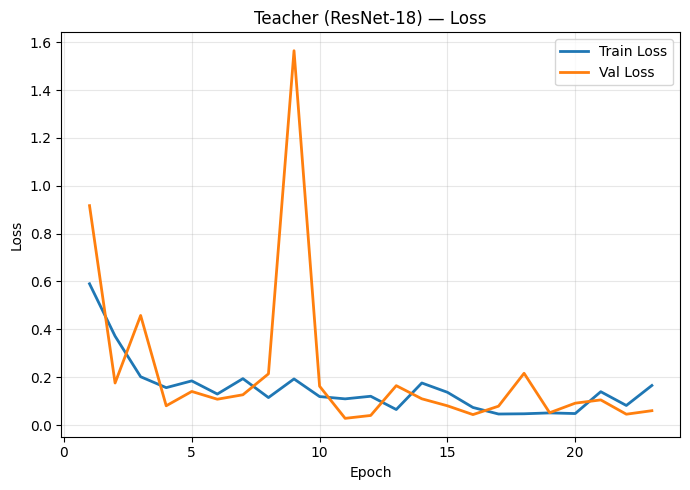

📊 Saved: /kaggle/working/teacher_curves_loss.png


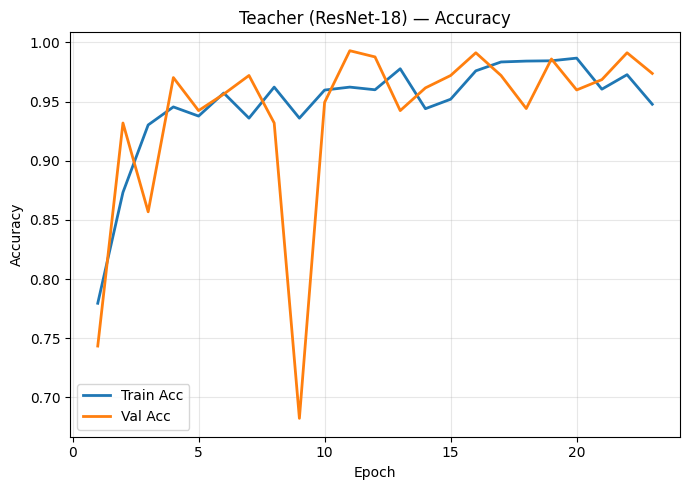

📊 Saved: /kaggle/working/teacher_curves_acc.png


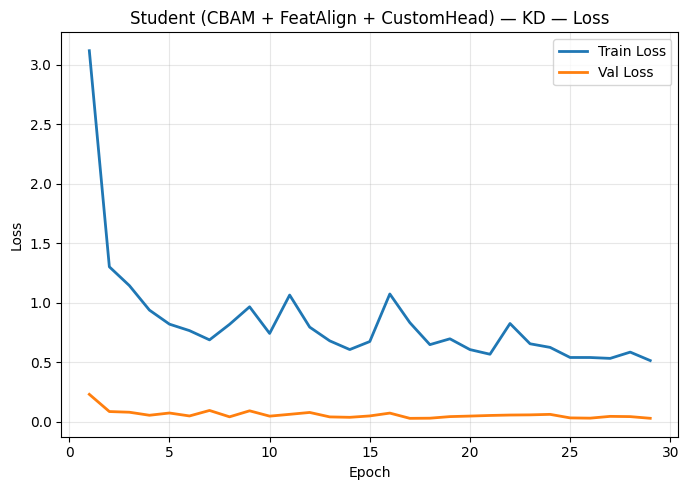

📊 Saved: /kaggle/working/student_curves_loss.png


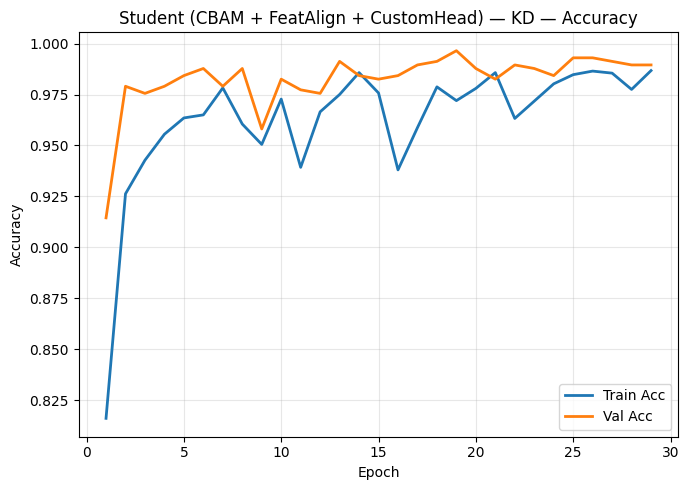

📊 Saved: /kaggle/working/student_curves_acc.png

🔍 Evaluating TEACHER on validation set ...

  Teacher (ResNet-18) — Val
  Accuracy  : 0.9930
  Precision : 0.9931
  Recall    : 0.9930
  F1 Score  : 0.9930
              precision    recall  f1-score   support

   1 Tk Back       1.00      0.99      1.00       140
  1 Tk Front       0.99      0.99      0.99       144
   2 Tk Back       1.00      1.00      1.00        70
  2 Tk Front       0.98      0.97      0.98        67
   5 Tk Back       1.00      1.00      1.00        77
  5 Tk Front       0.97      1.00      0.99        75

    accuracy                           0.99       573
   macro avg       0.99      0.99      0.99       573
weighted avg       0.99      0.99      0.99       573



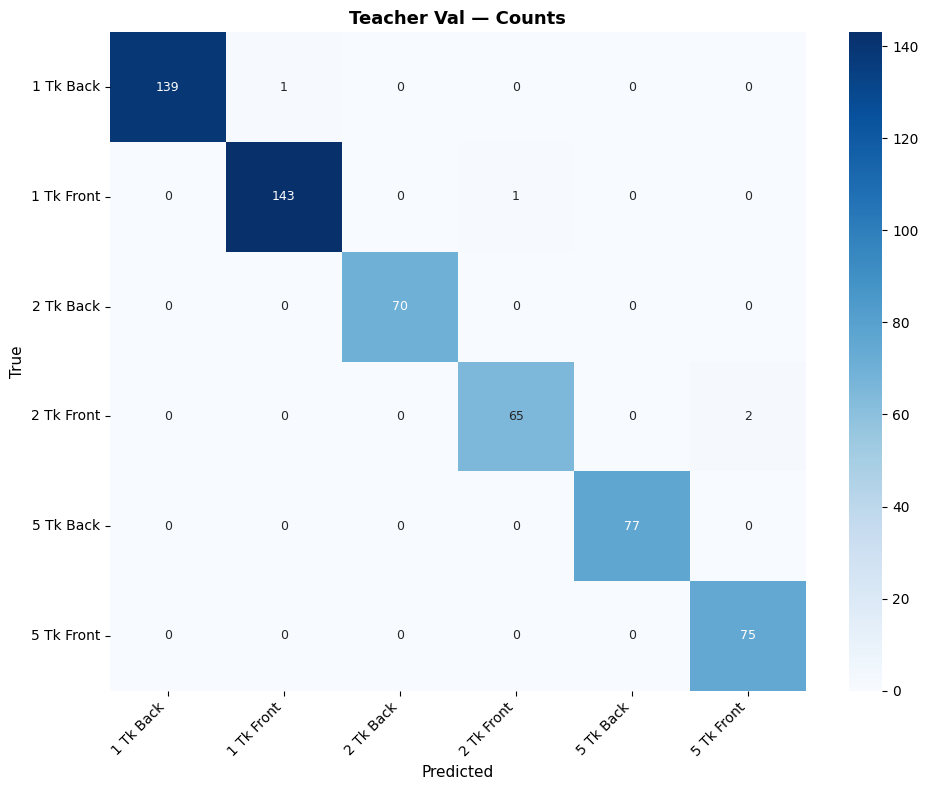

📊 Saved: /kaggle/working/cm_teacher_val_counts.png


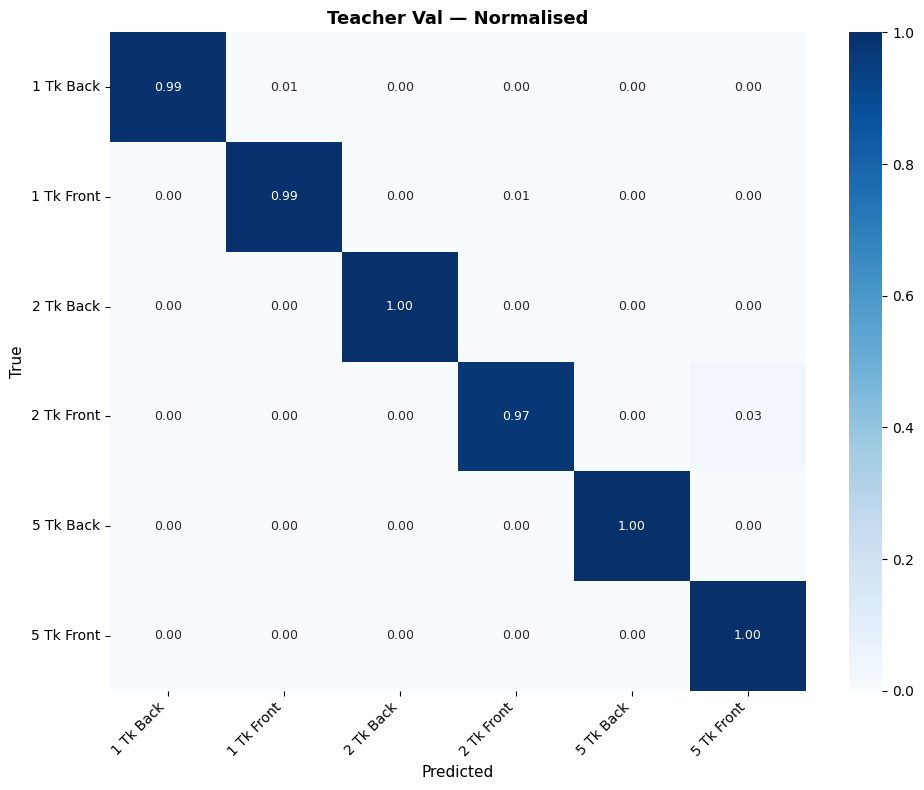

📊 Saved: /kaggle/working/cm_teacher_val_normalised.png

🔍 Evaluating TEACHER on test set ...

  Teacher (ResNet-18) — Test
  Accuracy  : 0.9816
  Precision : 0.9820
  Recall    : 0.9816
  F1 Score  : 0.9815
              precision    recall  f1-score   support

   1 Tk Back       1.00      0.99      0.99       279
  1 Tk Front       0.96      1.00      0.98       286
   2 Tk Back       0.99      0.99      0.99       141
  2 Tk Front       0.99      0.91      0.95       133
   5 Tk Back       0.99      1.00      1.00       154
  5 Tk Front       0.97      0.98      0.97       151

    accuracy                           0.98      1144
   macro avg       0.98      0.98      0.98      1144
weighted avg       0.98      0.98      0.98      1144



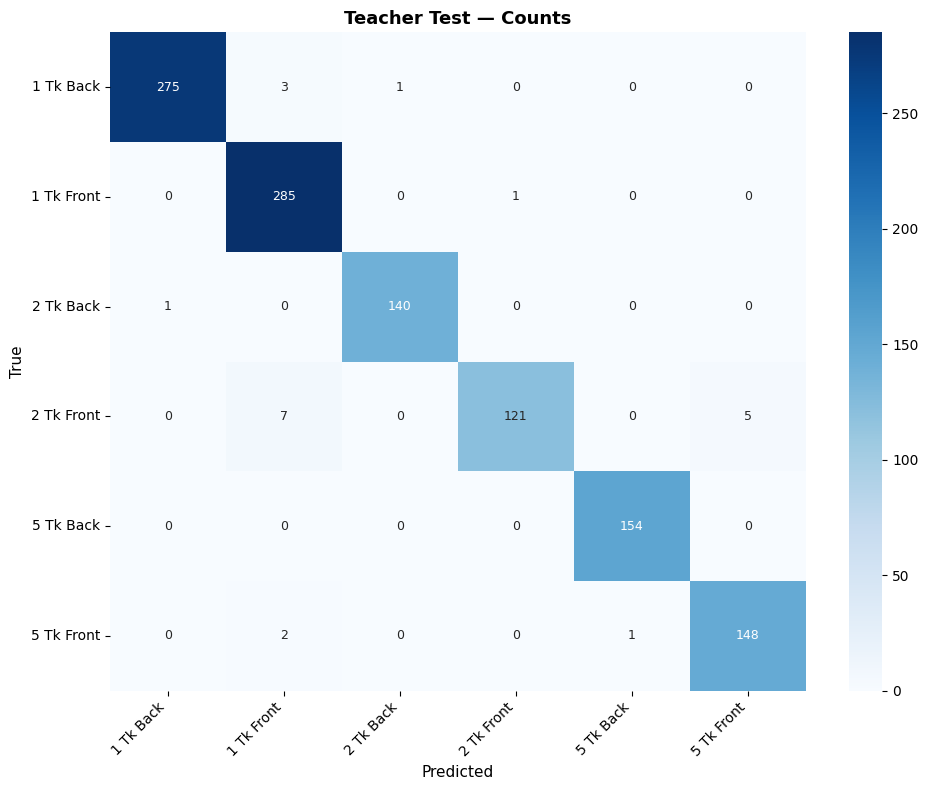

📊 Saved: /kaggle/working/cm_teacher_test_counts.png


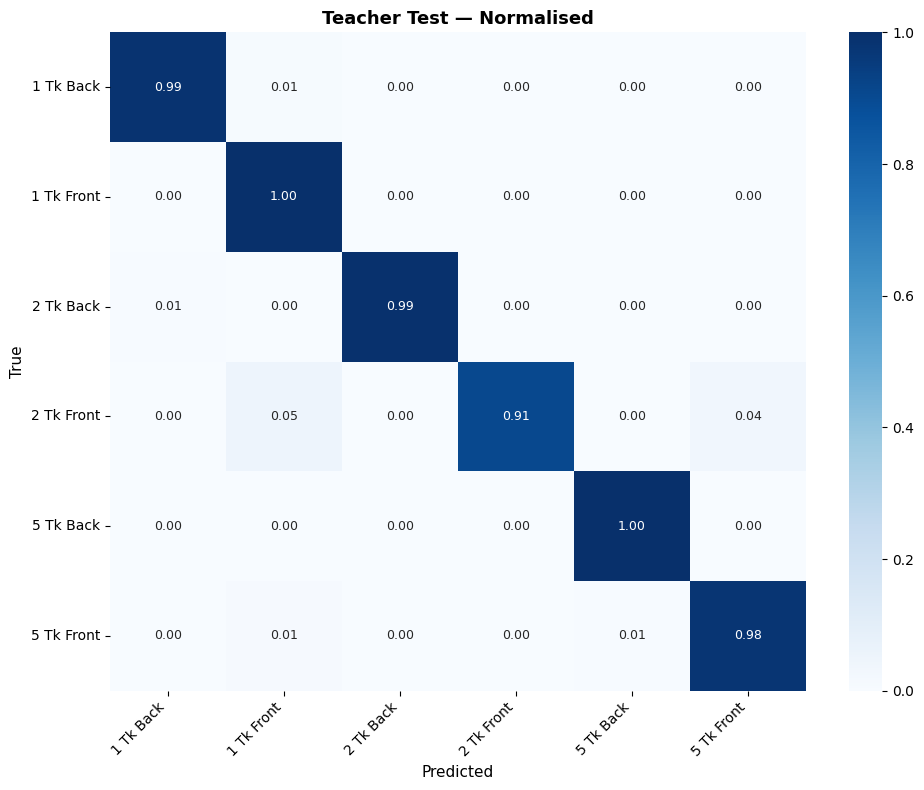

📊 Saved: /kaggle/working/cm_teacher_test_normalised.png

🔍 Evaluating STUDENT on validation set ...

  Proposed Student — Val
  Accuracy  : 0.9895
  Precision : 0.9897
  Recall    : 0.9895
  F1 Score  : 0.9896
              precision    recall  f1-score   support

   1 Tk Back       0.99      1.00      1.00       140
  1 Tk Front       0.99      0.99      0.99       144
   2 Tk Back       0.99      0.99      0.99        70
  2 Tk Front       0.96      0.99      0.97        67
   5 Tk Back       1.00      0.99      0.99        77
  5 Tk Front       1.00      0.99      0.99        75

    accuracy                           0.99       573
   macro avg       0.99      0.99      0.99       573
weighted avg       0.99      0.99      0.99       573



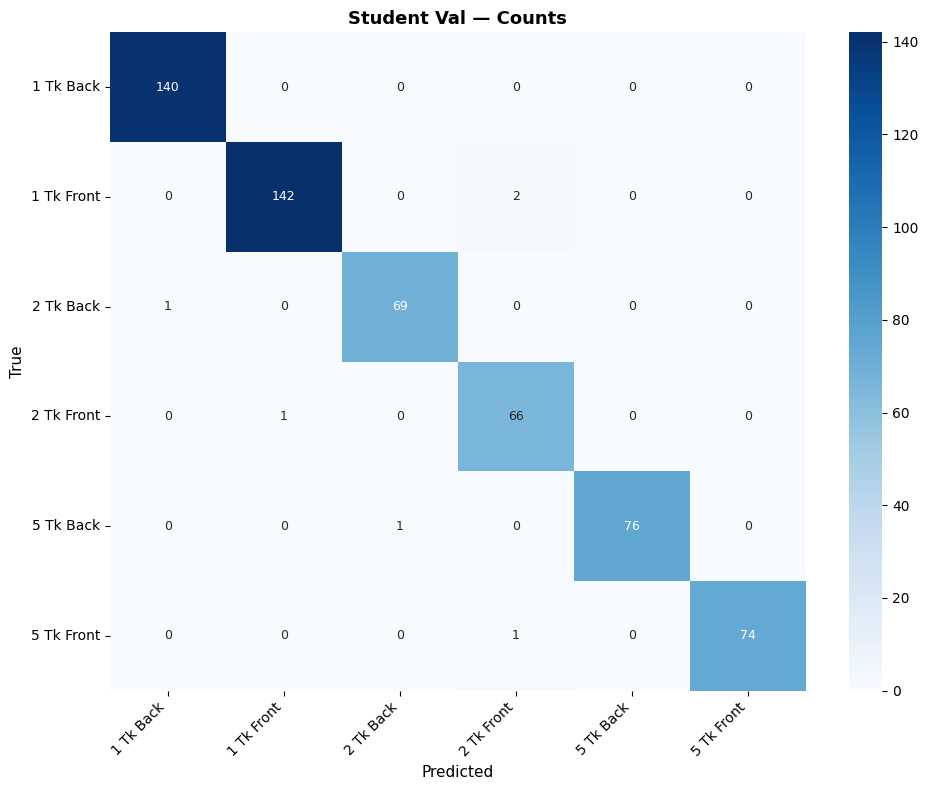

📊 Saved: /kaggle/working/cm_student_val_counts.png


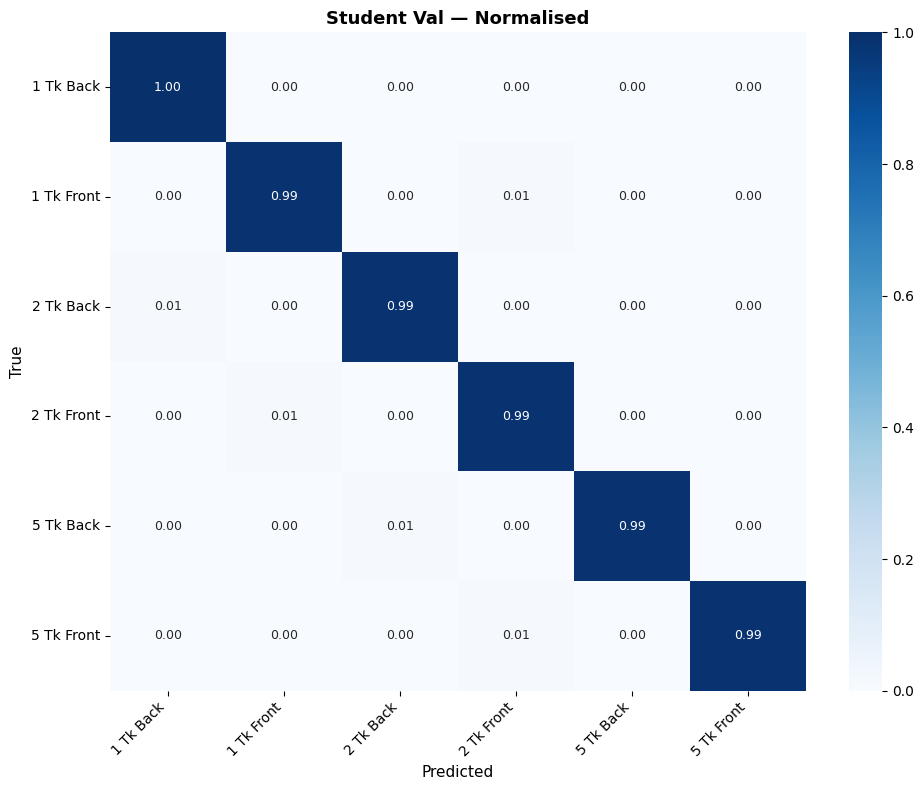

📊 Saved: /kaggle/working/cm_student_val_normalised.png

🔍 Evaluating STUDENT on test set ...

  Proposed Student — Test
  Accuracy  : 0.9904
  Precision : 0.9906
  Recall    : 0.9904
  F1 Score  : 0.9904
              precision    recall  f1-score   support

   1 Tk Back       1.00      1.00      1.00       279
  1 Tk Front       0.97      1.00      0.99       286
   2 Tk Back       0.99      0.99      0.99       141
  2 Tk Front       1.00      0.95      0.98       133
   5 Tk Back       0.99      0.99      0.99       154
  5 Tk Front       1.00      0.99      0.99       151

    accuracy                           0.99      1144
   macro avg       0.99      0.99      0.99      1144
weighted avg       0.99      0.99      0.99      1144



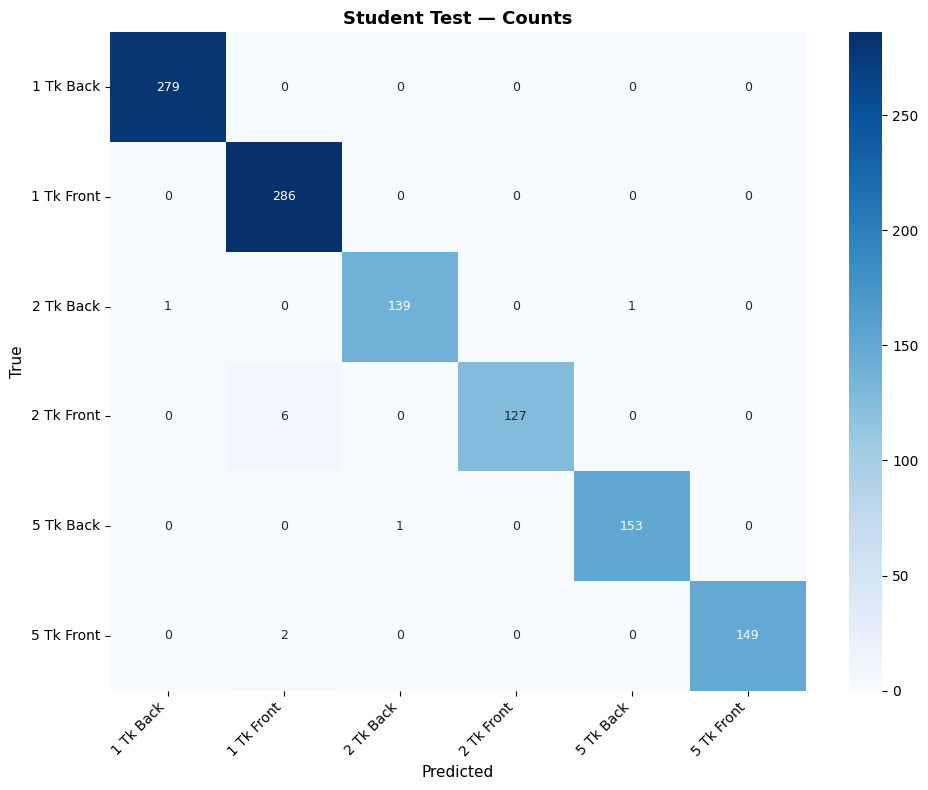

📊 Saved: /kaggle/working/cm_student_test_counts.png


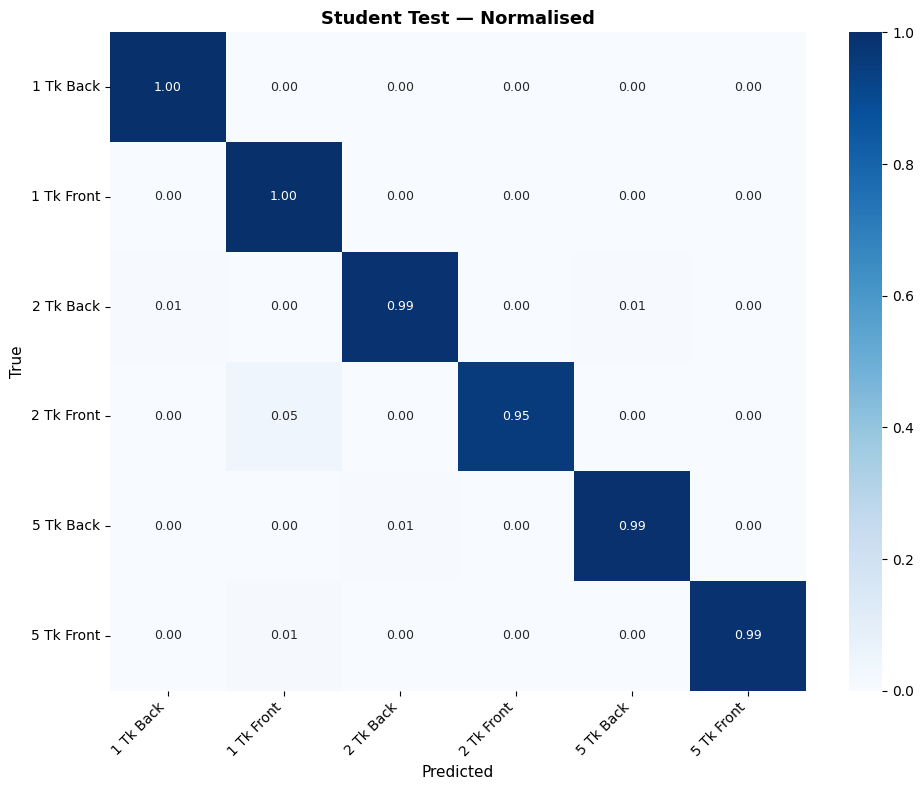

📊 Saved: /kaggle/working/cm_student_test_normalised.png

  📋  TEACHER vs PROPOSED STUDENT — Final Comparison

  [Validation Set]
  Metric          Teacher        Student
  --------------------------------------
  Accuracy         0.9930         0.9895
  Precision        0.9931         0.9897
  Recall           0.9930         0.9895
  F1               0.9930         0.9896

  [Test Set]
  Metric          Teacher        Student
  --------------------------------------
  Accuracy         0.9816         0.9904
  Precision        0.9820         0.9906
  Recall           0.9816         0.9904
  F1               0.9815         0.9904

📌 Final Train Accuracy:
   Teacher : 0.9478
   Student : 0.9868

🏗️  Proposed Student Architecture Summary:
   Backbone   : ShuffleNetV2-x1.0 (pretrained ImageNet)
   Attention  : CBAM after stage2(116ch), stage3(232ch), stage4(464ch)
   Feat Align : FeatureAlignmentAdapter(464→512) + MSE loss (λ=0.1)
   Head       : Linear(1024→256) → BN → GELU → Dropout(0.3) →

In [7]:
# ============================================================
# KNOWLEDGE DISTILLATION: ResNet18 (Teacher) → ShuffleNet (Student)
# Student: CBAM + Feature Alignment Adapter + Custom Head
# Coin Classification Task — Bangladesh Numismatic Dataset (10 Classes)
# ============================================================
print('start')
import os
import copy
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, classification_report
)

# ============================================================
# 1. DATASET SETUP — 6-CLASS BANGLADESH COIN DATASET (1/2/5 TAKA)
# ============================================================
# Classes (6 total):
#   1f → 1 Taka Front (1993, 1999, 2003, 2014)
#   1b → 1 Taka Back  (1993, 1999, 2003, 2014)
#   2f → 2 Taka Front (2008, 2013)
#   2b → 2 Taka Back  (2008, 2013)
#   5f → 5 Taka Front (2008, 2012)
#   5b → 5 Taka Back  (2008, 2012)
#
# Display names:
#   1f → "1 Tk Front"   1b → "1 Tk Back"
#   2f → "2 Tk Front"   2b → "2 Tk Back"
#   5f → "5 Tk Front"   5b → "5 Tk Back"
# ============================================================

IMG_SIZE   = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


SPLIT_ROOT = "/kaggle/working/coin_dataset_split"

train_dir = os.path.join(SPLIT_ROOT, "train")
val_dir   = os.path.join(SPLIT_ROOT, "val")
test_dir  = os.path.join(SPLIT_ROOT, "test")



train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)   # should be 6
CLASS_NAMES = train_dataset.classes        # sorted alphabetically by ImageFolder: ['1b','1f','2b','2f','5b','5f']

# Map raw folder names → readable display names for printouts/plots
DISPLAY_NAME_MAP = {
    "1f": "1 Tk Front", "1b": "1 Tk Back",
    "2f": "2 Tk Front", "2b": "2 Tk Back",
    "5f": "5 Tk Front", "5b": "5 Tk Back",
}
DISPLAY_NAMES = [DISPLAY_NAME_MAP.get(c, c) for c in CLASS_NAMES]

print(f"Train images      : {len(train_dataset)}")
print(f"Validation images : {len(val_dataset)}")
print(f"Test images       : {len(test_dataset)}")
print(f"Classes ({NUM_CLASSES})   : {DISPLAY_NAMES}")

# Sanity check — warn if unexpected class count
if NUM_CLASSES != 6:
    print(f"⚠️  WARNING: Expected 6 classes but found {NUM_CLASSES}. "
          f"Check your dataset folder structure.")

# ── Per-class image count ────────────────────────────────────
print("\n📦 Per-class distribution (train):")
from collections import Counter
label_counts = Counter(train_dataset.targets)
for idx, name in enumerate(CLASS_NAMES):
    print(f"   {DISPLAY_NAME_MAP.get(name, name):15s}: {label_counts[idx]:4d} images")
# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Using device: {device}")

# ============================================================
# 3. MODEL DEFINITIONS (architecture unchanged from original)
# ============================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        mid = max(in_channels // reduction_ratio, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        scale   = self.sigmoid(avg_out + max_out)
        return x * scale.unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                  padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        scale   = self.sigmoid(self.conv(
                      torch.cat([avg_out, max_out], dim=1)))
        return x * scale


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel=7):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_att = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x


class FeatureAlignmentAdapter(nn.Module):
    def __init__(self, student_channels: int, teacher_channels: int):
        super().__init__()
        self.proj = nn.Conv2d(student_channels, teacher_channels,
                               kernel_size=1, bias=False)
        self.bn   = nn.BatchNorm2d(teacher_channels)

    def forward(self, x):
        return self.bn(self.proj(x))


class CustomHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int,
                 hidden_dim: int = 256, dropout_p: float = 0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_features, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.head(x)


class CBAMShuffleNet(nn.Module):
    STUDENT_FEAT_CH = 464
    TEACHER_FEAT_CH = 512

    def __init__(self, num_classes: int,
                 head_hidden_dim: int = 256,
                 head_dropout: float  = 0.3):
        super().__init__()
        base = models.shufflenet_v2_x1_0(
            weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
        )
        self.conv1   = base.conv1
        self.maxpool = base.maxpool
        self.stage2  = base.stage2
        self.stage3  = base.stage3
        self.stage4  = base.stage4
        self.conv5   = base.conv5

        self.cbam2 = CBAM(116)
        self.cbam3 = CBAM(232)
        self.cbam4 = CBAM(464)

        self.align_adapter = FeatureAlignmentAdapter(
            self.STUDENT_FEAT_CH, self.TEACHER_FEAT_CH
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = CustomHead(
            in_features = 1024,
            num_classes = num_classes,
            hidden_dim  = head_hidden_dim,
            dropout_p   = head_dropout
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.cbam2(self.stage2(x))
        x = self.cbam3(self.stage3(x))
        x = self.cbam4(self.stage4(x))
        aligned_feat = self.align_adapter(x)
        x      = self.conv5(x)
        x      = self.pool(x).flatten(1)
        logits = self.head(x)
        if self.training:
            return logits, aligned_feat
        return logits


def build_teacher(num_classes: int):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def build_student(num_classes: int):
    return CBAMShuffleNet(num_classes).to(device)


teacher = build_teacher(NUM_CLASSES)
student = build_student(NUM_CLASSES)

print(f"\n📐 Teacher params : {sum(p.numel() for p in teacher.parameters()):,}")
print(f"📐 Student params : {sum(p.numel() for p in student.parameters()):,}")
print(f"   CustomHead    : {sum(p.numel() for p in student.head.parameters()):,}")
print(f"   CBAM total    : {sum(p.numel() for m in [student.cbam2, student.cbam3, student.cbam4] for p in m.parameters()):,}")
print(f"   Adapter       : {sum(p.numel() for p in student.align_adapter.parameters()):,}")


# ── Teacher layer4 hook ──────────────────────────────────────
teacher_feat_store = {}

def _teacher_hook(module, input, output):
    teacher_feat_store['layer4'] = output.detach()

teacher.layer4.register_forward_hook(_teacher_hook)
print("🔗 Teacher layer4 hook registered.")


# ============================================================
# 4. COMBINED KD + FEATURE ALIGNMENT LOSS (unchanged)
# ============================================================

class CombinedKDLoss(nn.Module):
    def __init__(self, temperature=4.0, alpha=0.4, lambda_feat=0.1):
        super().__init__()
        self.T           = temperature
        self.alpha       = alpha
        self.lambda_feat = lambda_feat
        self.ce          = nn.CrossEntropyLoss()
        self.mse         = nn.MSELoss()

    @staticmethod
    def _norm(t):
        mu  = t.mean(dim=[1, 2, 3], keepdim=True)
        std = t.std(dim=[1, 2, 3],  keepdim=True).clamp(min=1e-6)
        return (t - mu) / std

    def forward(self, student_logits, teacher_logits, labels,
                student_feat, teacher_feat):
        loss_ce   = self.ce(student_logits, labels)
        s_soft    = F.log_softmax(student_logits / self.T, dim=1)
        t_soft    = F.softmax(teacher_logits     / self.T, dim=1)
        loss_kd   = F.kl_div(s_soft, t_soft,
                              reduction="batchmean") * (self.T ** 2)
        loss_feat = self.mse(self._norm(student_feat),
                             self._norm(teacher_feat))
        total = (self.alpha       * loss_ce
               + (1 - self.alpha) * loss_kd
               + self.lambda_feat * loss_feat)
        return total, loss_ce.item(), loss_kd.item(), loss_feat.item()


# ============================================================
# 5. TRAINING UTILITIES (unchanged)
# ============================================================

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = None
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        model.load_state_dict(self.best_state)


def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


# ============================================================
# 6. HYPERPARAMETERS
# ============================================================

EPOCHS      = 100
PATIENCE    = 12
LR_TEACHER  = 1e-3
LR_STUDENT  = 1e-3
TEMPERATURE = 4.0
ALPHA       = 0.4
LAMBDA_FEAT = 0.1

# ============================================================
# 7. TEACHER TRAINING
# ============================================================

print("\n" + "="*55)
print("  PHASE 1 — Training Teacher (ResNet-18)")
print("="*55)

teacher_optimizer = AdamW(teacher.parameters(), lr=LR_TEACHER, weight_decay=1e-4)
teacher_scheduler = CosineAnnealingLR(teacher_optimizer, T_max=EPOCHS)
teacher_criterion = nn.CrossEntropyLoss()
teacher_es        = EarlyStopping(patience=PATIENCE)

teacher_train_losses, teacher_val_losses = [], []
teacher_train_accs,   teacher_val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    teacher.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        teacher_optimizer.zero_grad()
        out  = teacher(imgs)
        loss = teacher_criterion(out, labels)
        loss.backward()
        teacher_optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (out.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    teacher_scheduler.step()

    t_loss = running_loss / total
    t_acc  = correct / total
    v_loss, v_acc = evaluate(teacher, val_loader)

    teacher_train_losses.append(t_loss)
    teacher_val_losses.append(v_loss)
    teacher_train_accs.append(t_acc)
    teacher_val_accs.append(v_acc)

    print(f"[Teacher] Epoch {epoch:03d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

    if teacher_es.step(v_loss, teacher):
        print(f"  ⏹  Early stopping at epoch {epoch}")
        break

teacher_es.restore_best(teacher)
print("✅ Teacher training complete. Best val loss restored.")


# ============================================================
# 8. STUDENT TRAINING
# ============================================================

print("\n" + "="*55)
print("  PHASE 2 — Training Student (CBAM + FeatAlign + CustomHead)")
print("="*55)

student_optimizer = AdamW(student.parameters(), lr=LR_STUDENT, weight_decay=1e-4)
student_scheduler = CosineAnnealingLR(student_optimizer, T_max=EPOCHS)
combined_loss_fn  = CombinedKDLoss(temperature=TEMPERATURE,
                                    alpha=ALPHA,
                                    lambda_feat=LAMBDA_FEAT)
student_es        = EarlyStopping(patience=PATIENCE)

student_train_losses, student_val_losses = [], []
student_train_accs,   student_val_accs   = [], []

teacher.eval()

for epoch in range(1, EPOCHS + 1):
    student.train()
    running_loss  = 0.0
    running_ce    = 0.0
    running_kd    = 0.0
    running_feat  = 0.0
    correct       = 0
    total         = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            teacher_logits = teacher(imgs)
            teacher_feat   = teacher_feat_store['layer4']

        student_optimizer.zero_grad()
        student_logits, student_feat = student(imgs)

        loss, lce, lkd, lfeat = combined_loss_fn(
            student_logits, teacher_logits, labels,
            student_feat, teacher_feat
        )

        loss.backward()
        student_optimizer.step()

        n = imgs.size(0)
        running_loss += loss.item() * n
        running_ce   += lce  * n
        running_kd   += lkd  * n
        running_feat += lfeat * n
        correct      += (student_logits.argmax(1) == labels).sum().item()
        total        += n

    student_scheduler.step()

    s_loss = running_loss / total
    s_ce   = running_ce   / total
    s_kd   = running_kd   / total
    s_feat = running_feat / total
    s_acc  = correct      / total
    v_loss, v_acc = evaluate(student, val_loader)

    student_train_losses.append(s_loss)
    student_val_losses.append(v_loss)
    student_train_accs.append(s_acc)
    student_val_accs.append(v_acc)

    print(f"[Student] Epoch {epoch:03d}/{EPOCHS} | "
          f"Loss: {s_loss:.4f} "
          f"(CE:{s_ce:.3f} KD:{s_kd:.3f} Feat:{s_feat:.3f}) | "
          f"Train Acc: {s_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

    if student_es.step(v_loss, student):
        print(f"  ⏹  Early stopping at epoch {epoch}")
        break

student_es.restore_best(student)
print("✅ Student training complete. Best val loss restored.")


# ============================================================
# 9. SAVE MODELS
# ============================================================

torch.save(teacher.state_dict(), "/kaggle/working/teacher_resnet18_bd_coin.pth")
torch.save(student.state_dict(), "/kaggle/working/student_cbam_shufflenet_bd_coin.pth")
print("💾 Models saved.")


# ============================================================
# 10. LEARNING CURVES
# ============================================================

def plot_curves(train_losses, val_losses, train_accs, val_accs,
                 title_prefix, save_path_prefix):
    ep = range(1, len(train_losses) + 1)

    # ---- Loss curve (its own image) ----
    plt.figure(figsize=(7, 5))
    plt.plot(ep, train_losses, label="Train Loss", linewidth=2)
    plt.plot(ep, val_losses,   label="Val Loss",   linewidth=2)
    plt.title(f"{title_prefix} — Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    loss_path = f"{save_path_prefix}_loss.png"
    plt.savefig(loss_path, dpi=150)
    plt.show()
    print(f"📊 Saved: {loss_path}")

    # ---- Accuracy curve (its own image) ----
    plt.figure(figsize=(7, 5))
    plt.plot(ep, train_accs, label="Train Acc", linewidth=2)
    plt.plot(ep, val_accs,   label="Val Acc",   linewidth=2)
    plt.title(f"{title_prefix} — Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    acc_path = f"{save_path_prefix}_acc.png"
    plt.savefig(acc_path, dpi=150)
    plt.show()
    print(f"📊 Saved: {acc_path}")


plot_curves(teacher_train_losses, teacher_val_losses,
            teacher_train_accs,   teacher_val_accs,
            "Teacher (ResNet-18)",
            "/kaggle/working/teacher_curves")

plot_curves(student_train_losses, student_val_losses,
            student_train_accs,   student_val_accs,
            "Student (CBAM + FeatAlign + CustomHead) — KD",
            "/kaggle/working/student_curves")


# ============================================================
# 11. FULL EVALUATION
# ============================================================

def full_evaluation(model, loader, model_name="Model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc       = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds,
                                 average="weighted", zero_division=0)
    recall    = recall_score(all_labels, all_preds,
                              average="weighted", zero_division=0)
    f1        = f1_score(all_labels, all_preds,
                          average="weighted", zero_division=0)

    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(classification_report(all_labels, all_preds,
                             target_names=DISPLAY_NAMES, zero_division=0))
    return all_preds, all_labels, acc, precision, recall, f1


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

def plot_confusion_matrix(labels, preds, class_names, title, save_path_prefix):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # ---- Counts (its own image) ----
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 9})
    plt.title(f"{title} — Counts", fontsize=13, fontweight='bold')
    plt.xlabel("Predicted", fontsize=11)
    plt.ylabel("True", fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    counts_path = f"{save_path_prefix}_counts.png"
    plt.savefig(counts_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Saved: {counts_path}")

    # ---- Normalised (its own image) ----
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 9})
    plt.title(f"{title} — Normalised", fontsize=13, fontweight='bold')
    plt.xlabel("Predicted", fontsize=11)
    plt.ylabel("True", fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    norm_path = f"{save_path_prefix}_normalised.png"
    plt.savefig(norm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Saved: {norm_path}")


# ============================================================
# 13. RUN EVALUATIONS
# ============================================================

print("\n🔍 Evaluating TEACHER on validation set ...")
t_val_preds, t_val_labels, *_ = full_evaluation(
    teacher, val_loader, "Teacher (ResNet-18) — Val")
plot_confusion_matrix(t_val_labels, t_val_preds, DISPLAY_NAMES,
                      "Teacher Val", "/kaggle/working/cm_teacher_val")

print("\n🔍 Evaluating TEACHER on test set ...")
t_test_preds, t_test_labels, *_ = full_evaluation(
    teacher, test_loader, "Teacher (ResNet-18) — Test")
plot_confusion_matrix(t_test_labels, t_test_preds, DISPLAY_NAMES,
                      "Teacher Test", "/kaggle/working/cm_teacher_test")

print("\n🔍 Evaluating STUDENT on validation set ...")
s_val_preds, s_val_labels, *_ = full_evaluation(
    student, val_loader, "Proposed Student — Val")
plot_confusion_matrix(s_val_labels, s_val_preds, DISPLAY_NAMES,
                      "Student Val", "/kaggle/working/cm_student_val")

print("\n🔍 Evaluating STUDENT on test set ...")
s_test_preds, s_test_labels, *_ = full_evaluation(
    student, test_loader, "Proposed Student — Test")
plot_confusion_matrix(s_test_labels, s_test_preds, DISPLAY_NAMES,
                      "Student Test", "/kaggle/working/cm_student_test")


# ============================================================
# 14. TEACHER vs STUDENT COMPARISON TABLE
# ============================================================

def get_metrics(model, loader):
    model.eval()
    pl, ll = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            pl.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
            ll.extend(labels.numpy())
    p, l = np.array(pl), np.array(ll)
    return {
        "Accuracy" : accuracy_score(l, p),
        "Precision": precision_score(l, p, average="weighted", zero_division=0),
        "Recall"   : recall_score(l, p,    average="weighted", zero_division=0),
        "F1"       : f1_score(l, p,        average="weighted", zero_division=0),
    }

print("\n" + "="*55)
print("  📋  TEACHER vs PROPOSED STUDENT — Final Comparison")
print("="*55)
for split_name, loader in [("Validation", val_loader), ("Test", test_loader)]:
    tm = get_metrics(teacher, loader)
    sm = get_metrics(student, loader)
    print(f"\n  [{split_name} Set]")
    print(f"  {'Metric':<12} {'Teacher':>10} {'Student':>14}")
    print(f"  {'-'*38}")
    for k in tm:
        print(f"  {k:<12} {tm[k]:>10.4f} {sm[k]:>14.4f}")


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n📌 Final Train Accuracy:")
print(f"   Teacher : {teacher_train_accs[-1]:.4f}")
print(f"   Student : {student_train_accs[-1]:.4f}")

print("\n🏗️  Proposed Student Architecture Summary:")
print(f"   Backbone   : ShuffleNetV2-x1.0 (pretrained ImageNet)")
print(f"   Attention  : CBAM after stage2(116ch), stage3(232ch), stage4(464ch)")
print(f"   Feat Align : FeatureAlignmentAdapter(464→512) + MSE loss (λ={LAMBDA_FEAT})")
print(f"   Head       : Linear(1024→256) → BN → GELU → Dropout(0.3) → Linear(256→{NUM_CLASSES})")
print(f"   KD Loss    : CE(α={ALPHA}) + KL(T={TEMPERATURE}) + FeatMSE(λ={LAMBDA_FEAT})")
print(f"   Total params: {sum(p.numel() for p in student.parameters()):,}")

print(f"\n📂 Dataset: Bangladesh Numismatic Coin Dataset")
print(f"   Classes ({NUM_CLASSES}): {DISPLAY_NAMES}")
print(f"   Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

print("\n✅ All done! Check /kaggle/working/ for saved models and plots.")

In [8]:
def find_worst_val_samples(model, dataset, loader, top_k=10):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')
    losses, paths = [], []
    idx = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            batch_losses = criterion(out, labels)
            for bl in batch_losses.cpu().numpy():
                losses.append(bl)
                paths.append(dataset.samples[idx][0])
                idx += 1

    order = np.argsort(losses)[::-1][:top_k]
    print(f"\n🔍 Top {top_k} highest-loss validation samples:")
    for i in order:
        print(f"  loss={losses[i]:.4f}  →  {paths[i]}")
    return [(paths[i], losses[i]) for i in order]

find_worst_val_samples(teacher, val_dataset, val_loader)


🔍 Top 10 highest-loss validation samples:
  loss=3.2383  →  /kaggle/working/coin_dataset_split/val/1b/1Taka_2014Back_1Taka_2014Back(150).jpg
  loss=2.9778  →  /kaggle/working/coin_dataset_split/val/1f/1Taka_2003Front_1Taka_2003Front(39).jpg
  loss=2.4380  →  /kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(267).jpg
  loss=1.1414  →  /kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(170).jpg
  loss=0.5559  →  /kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(10).jpg
  loss=0.3745  →  /kaggle/working/coin_dataset_split/val/1f/1Taka_2014Front_1Taka_2014Front(73).jpg
  loss=0.3639  →  /kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(262).jpg
  loss=0.3326  →  /kaggle/working/coin_dataset_split/val/1f/1Taka_2003Front_1Taka_2003Front(46).jpg
  loss=0.2800  →  /kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(47).jpg
  loss=0.2738  →  /kaggle/working/coin_dataset_split/va

[('/kaggle/working/coin_dataset_split/val/1b/1Taka_2014Back_1Taka_2014Back(150).jpg',
  np.float32(3.2383125)),
 ('/kaggle/working/coin_dataset_split/val/1f/1Taka_2003Front_1Taka_2003Front(39).jpg',
  np.float32(2.9778326)),
 ('/kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(267).jpg',
  np.float32(2.4380145)),
 ('/kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(170).jpg',
  np.float32(1.1413952)),
 ('/kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(10).jpg',
  np.float32(0.555868)),
 ('/kaggle/working/coin_dataset_split/val/1f/1Taka_2014Front_1Taka_2014Front(73).jpg',
  np.float32(0.37453595)),
 ('/kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(262).jpg',
  np.float32(0.363908)),
 ('/kaggle/working/coin_dataset_split/val/1f/1Taka_2003Front_1Taka_2003Front(46).jpg',
  np.float32(0.3326292)),
 ('/kaggle/working/coin_dataset_split/val/2f/2Taka_2013Front_2Taka_2013Front(47).jpg',
  np.flo